# Mini-Projet : Système intelligent d’analyse des ventes

Etapes
- Compréhension du problème (Business Understanding)
- Analyse exploratoire des données (EDA)
- Prétraitement des données
- Modélisation Machine Learning
- Évaluation du modèle
- Architecture du système
- Déploiement (MLOps)

##  I. Description du problème

1) Compréhension du problème (Business Understanding)

**Objectifs**

Le système doit :
- analyser les ventes
- prévoir les ventes futures
- détecter les fraudes / anomalies
- être déployé sur Internet

Questions à répondre
- Quelles variables influencent les ventes ?
- Quel indicateur veut-on prédire ?

Exemple : Sales=Quantity×UnitPrice

Donc la variable cible peut être : Sales

## II. Analyse des données

In [95]:
# Import des librairies
import matplotlib.pyplot as plt
from module.utils import *

import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

2) Analyse exploratoire des données

In [96]:
# Chargement
df = load_data("data/online_retail.csv")
df.shape

(541909, 8)

In [97]:
# 5 premiers lignes
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [98]:
# Structure des données
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [99]:
# Stats de bases
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [100]:
# Vérifier les valeurs manquantes
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [101]:
# Données dupliquées
df.duplicated().sum()

np.int64(5268)

In [102]:
# Suppression des NA et données dupliquées
df_copy = df.copy()
df = clean_data(df_copy)

In [103]:
df.shape

(392692, 8)

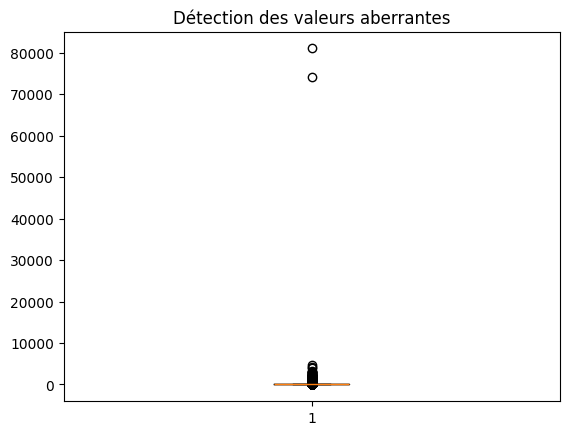

In [104]:
# Boxplot pour outliers
plt.boxplot(df["Quantity"])
plt.title("Détection des valeurs aberrantes")
plt.show()

3) Prétraitement des données

In [105]:
# Feature engineering
create_target(df) # Valeur cible
create_time_features(df)

cols = ["Sales", "InvoiceDate", "Month", "Day", "WeekDay"]
df[cols].head()

,Sales,InvoiceDate,Month,Day,WeekDay
0,15.30,2010-12-01 08:26:00,12,1,2
1,20.34,2010-12-01 08:26:00,12,1,2
2,22.00,2010-12-01 08:26:00,12,1,2
3,20.34,2010-12-01 08:26:00,12,1,2
4,20.34,2010-12-01 08:26:00,12,1,2


## III. Choix des modèles

In [106]:
X_sales, y = prepare_sales_features(df)
X_fraud = prepare_fraud_features(df)

In [107]:

seed = 42

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_sales, y,
    test_size=0.2,
    random_state=seed
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (314153, 6)
Test shape: (78539, 6)


A) Prédiction des ventes

C’est un problème de régression

Modèles recommandés :
- Random Forest
- XGBoost

Raison :
- XGBoost pour la performance
- Random Forest pour la simplicité

In [108]:
# =========================
# Random Forest
# =========================
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=seed,
    n_jobs=-1 # nombre de processeurs (-1 tout)
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_metrics  = evaluate_regression(y_test, rf_pred)
print_metrics(rf_metrics, "Random Forest")


===== RANDOM FOREST =====
RMSE : 426.5400
MAE  : 4.1582
R2   : 0.5039


In [109]:
# =========================
# XGBoost
# =========================
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=seed
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_metrics  = evaluate_regression(y_test, xgb_pred)
print_metrics(xgb_metrics, "XGBoost")


===== XGBOOST =====
RMSE : 327.4534
MAE  : 3.1634
R2   : 0.7076


### Evaluation

In [110]:
# Comparaison
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "RMSE": [rf_metrics['RMSE'], xgb_metrics['RMSE']],
    "MAE": [rf_metrics['MAE'], xgb_metrics['MAE']],
    "R2 Score": [rf_metrics['R2'], xgb_metrics['R2']]
})

results

,Model,RMSE,MAE,R2 Score
0,Random Forest,426.540044,4.158223,0.503939
1,XGBoost,327.453358,3.163403,0.707642


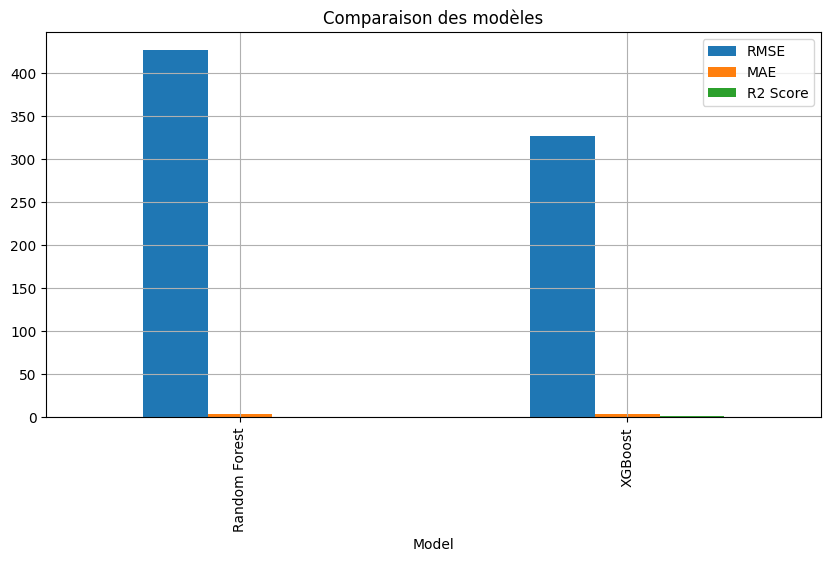

In [111]:
results.plot(
    x="Model",
    y=["RMSE", "MAE", "R2 Score"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparaison des modèles")
plt.grid(True)
plt.show()

- RMSE plus faible → 327.45 < 426.54
- R² plus élevé → 0.70 > 0.50

XGBoost est meilleur.

In [112]:
joblib.dump(xgb_model, "model/sales_model.pkl")

print("\nModèle sauvegardé : model/sales_model.pkl")


Modèle sauvegardé : model/sales_model.pkl


B) Détection d’anomalies

Utiliser :
- Isolation Forest
- Local Outlier Factor

Je recommande :
- Isolation Forest

car très adapté aux fraudes.

In [113]:
# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_fraud)

print(X_fraud.shape)

(392692, 3)


In [114]:
iso_model = IsolationForest(
    contamination=0.02,
    random_state=42,
    n_estimators=100
)

iso_model.fit_predict(X_scaled)

array([1, 1, 1, ..., 1, 1, 1], shape=(392692,))

In [115]:
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02,
    novelty=True
)

lof_model.fit(X_scaled)

,"n_neighbors n_neighbors: int, default=20Number of neighbors to use by default for :meth:`kneighbors` queries.If n_neighbors is larger than the number of samples provided,all samples will be used.",20
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf is size passed to :class:`BallTree` or :class:`KDTree`. This canaffect the speed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:func:`sklearn.metrics.pairwise_distances`. When p = 1, thisis equivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. When fitting this is used to define thethreshold on the scores of the samples.- if 'auto', the threshold is determined as in the original paper,- if a float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"novelty novelty: bool, default=FalseBy default, LocalOutlierFactor is only meant to be used for outlierdetection (novelty=False). Set novelty to True if you want to useLocalOutlierFactor for novelty detection. In this case be aware thatyou should only use predict, decision_function and score_sampleson new unseen data and not on the training set; and note that theresults obtained this way may differ from the standard LOF results... versionadded:: 0.20",True
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [116]:
X = df[["Quantity", "UnitPrice", "Sales"]]

# 1. Fit du scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Entraînement LOF
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02,
    novelty=True
)

lof_model.fit(X_scaled)

# 3. Sauvegarde
joblib.dump(lof_model, "model/fraud_model.pkl")
joblib.dump(scaler, "model/fraud_scaler.pkl")

['model/fraud_scaler.pkl']

### Evaluation

In [117]:
comparison = pd.DataFrame({
    "Model": ["Isolation Forest", "Local Outlier Factor"],
    "Nb anomalies": [if_count, lof_count]
})

comparison

,Model,Nb anomalies
0,Isolation Forest,7374
1,Local Outlier Factor,7851


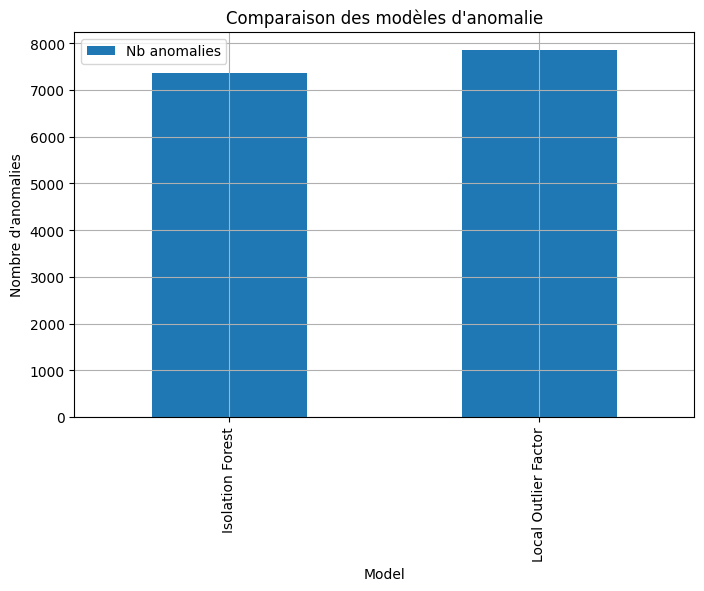

In [118]:
comparison.plot(
    x="Model",
    y="Nb anomalies",
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparaison des modèles d'anomalie")
plt.ylabel("Nombre d'anomalies")
plt.grid(True)
plt.show()

In [119]:
joblib.dump(lof_model, "model/fraud_model.pkl")
joblib.dump(scaler, "model/fraud_scaler.pkl")

['model/fraud_scaler.pkl']

## IV. Architecture du système

Data (CSV / Base de données)

        ↓

Prétraitement

        ↓

Modèle ML

        ↓

API FastAPI

        ↓

Interface Streamlit

        ↓

Utilisateur

## V. Proposition de déploiement

# VI. Demo